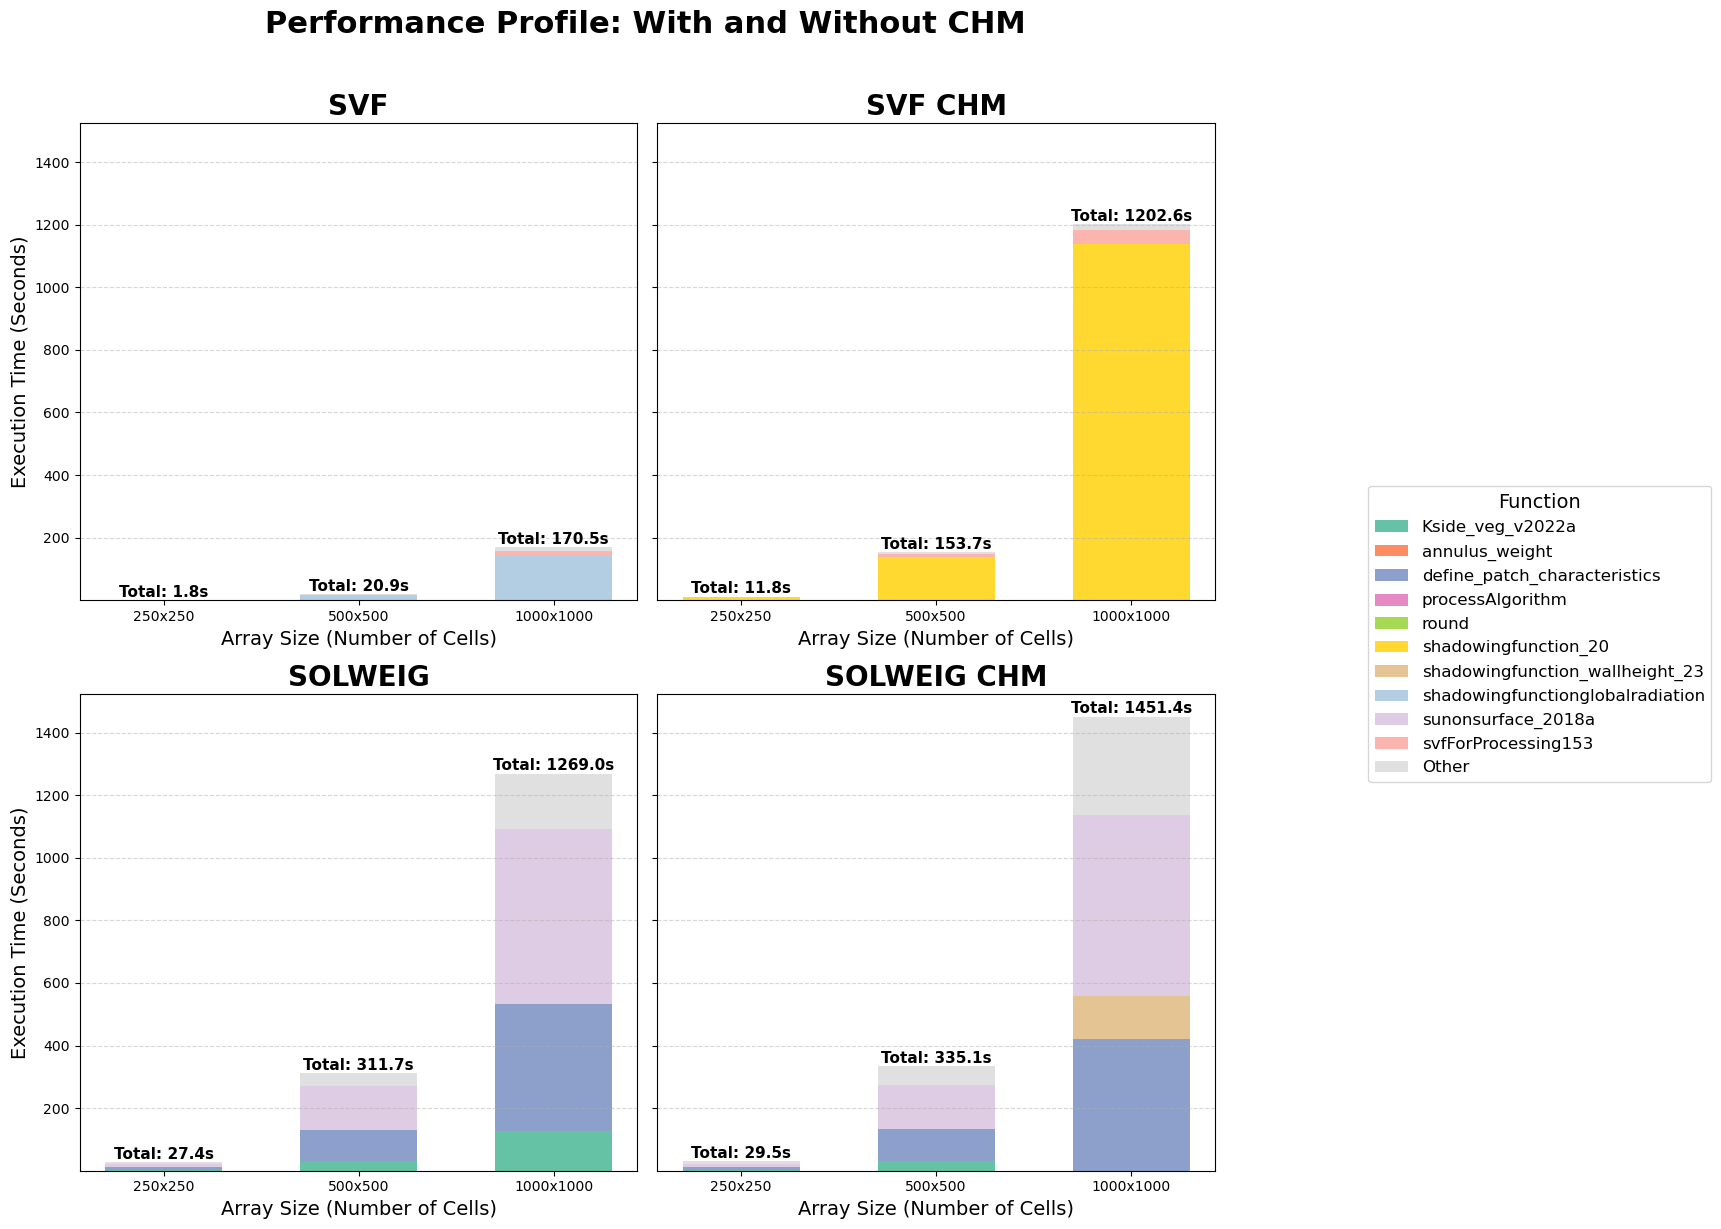

In [12]:
import matplotlib.pyplot as plt
import re
import os
from collections import defaultdict

# Function to process the profile data
def process_profile(files, base_dir):
    """
    Processes profile text files to extract top 3 functions by 'tottime'
    and the total 'cumtime' for each specified file.
    """
    pattern = re.compile(r'\s*\d+[\d/]*\s+(\S+)\s+\S+\s+(\S+)\s+\S+\s+(.+):\d+\((.+)\)')

    top3_times = defaultdict(list) # Stores top 3 functions (tottime, func_name) for each array size
    total_times = {} # Stores total cumtime for each array size

    for label, filename in files.items():
        path = os.path.join(base_dir, filename)
        if not os.path.exists(path):
            print(f"File not found: {path}")
            continue

        with open(path, 'r', encoding='latin1') as f:
            lines = f.readlines()

        data = []
        max_cumtime = 0
        for line in lines:
            match = pattern.match(line)
            if match:
                tottime = float(match.group(1)) # Self time of the function
                cumtime = float(match.group(2)) # Cumulative time of the function
                func_name = match.group(4) # Extracted function name
                data.append((tottime, func_name))
                if cumtime > max_cumtime:
                    max_cumtime = cumtime

        total_times[label] = max_cumtime

        top3 = sorted(data, key=lambda x: -x[0])[:3]
        top3_times[label] = top3

    return top3_times, total_times

# --- Data Definition and Processing ---

# Base directory for profile files
base_dir = "D:/Geomatics/optimization_tests_computer/"

# File paths for SOLWEIG data (without and with trees)
solweig_files = {
    "250x250": "250/profile_results_umep.txt",
    "500x500": "500/profile_results_umep.txt",
    "1000x1000": "1000/profile_results_umep.txt",
}

solweig_chm_files = {
    "250x250": "250/profile_results_umep_chm.txt",
    "500x500": "500/profile_results_umep_chm.txt",
    "1000x1000": "1000/profile_results_umep_chm.txt",
}

# File paths for SVF data (without and with trees)
svf_files = {
    "250x250": "250/svf_profile_results_umep.txt",
    "500x500": "500/svf_profile_results_umep.txt",
    "1000x1000": "1000/svf_profile_results_umep.txt",
}

svf_chm_files = {
    "250x250": "250/svf_profile_results_umep_chm.txt",
    "500x500": "500/svf_profile_results_umep_chm.txt",
    "1000x1000": "1000/svf_profile_results_umep_chm.txt",
}

# Process all four datasets
top3_solweig, total_solweig = process_profile(solweig_files, base_dir)
top3_solweig_chm, total_solweig_chm = process_profile(solweig_chm_files, base_dir)
top3_svf, total_svf = process_profile(svf_files, base_dir)
top3_svf_chm, total_svf_chm = process_profile(svf_chm_files, base_dir)

# --- Plotting Configuration ---

# Combine all unique function names from all datasets for consistent coloring
all_funcs_set = set()
for dataset_top3 in [top3_solweig, top3_solweig_chm, top3_svf, top3_svf_chm]:
    for v in dataset_top3.values():
        for _, name in v:
            all_funcs_set.add(name)

all_funcs = sorted(list(all_funcs_set)) # Sort for consistent ordering in legend

custom_colors = [
    '#66c2a5',  # Soft Teal
    '#fc8d62',  # Soft Orange
    '#8da0cb',  # Soft Blue-Purple
    '#e78ac3',  # Soft Pink
    '#a6d854',  # Soft Green
    '#ffd92f',  # Soft Yellow
    '#e5c494',  # Soft Brown
    '#b3cde3',  # Light Blue
    '#decbe4',  # Light Purple
    '#fbb4ae',  # Light Red
    '#fed9a6',  # Light Orange
    '#fddaec',  # Lighter Pink
    '#b4b4b4',  # Medium Light Gray
    '#ffed6f',  # Pale Yellow
    '#a6761d',  # Darker Brown
    '#6a3d9a',  # Dark Purple
    '#cab2d6',  # Lilac
    '#fdbf6f',  # Peach
    '#ff7f00',  # Bright Orange
    '#e31a1c',  # Bright Red
    '#33a02c',  # Bright Green
    '#1f78b4',  # Bright Blue
    '#e0e0e0'   # Light Grey for 'Other'
]

# Map functions to colors
func_colors = {func: custom_colors[i % (len(custom_colors) - 1)] for i, func in enumerate(all_funcs)}
func_colors["Other"] = custom_colors[-1] # Assign the last color to 'Other'

plot_data = [
    (top3_svf, total_svf, "SVF"),
    (top3_svf_chm, total_svf_chm, "SVF CHM"),
    (top3_solweig, total_solweig, "SOLWEIG"),
    (top3_solweig_chm, total_solweig_chm, "SOLWEIG CHM"),
]

# --- Create the 2x2 Plot ---

fig, axs = plt.subplots(2, 2, figsize=(13, 12), sharey=True)
axs = axs.flatten()

fig.suptitle("Performance Profile: With and Without CHM", fontsize=22, fontweight='bold', y=1.02)

added_legend_funcs = set()

bar_width = 0.6

for i, (top3, total, title) in enumerate(plot_data):
    ax = axs[i]
    labels = list(top3.keys())
    bottoms = [0] * len(labels)

    for func in all_funcs:
        values = []
        for label in labels:
            match = next(((time, name) for time, name in top3[label] if name == func), (0, func))
            values.append(match[0])

        ax.bar(labels, values, bottom=bottoms, color=func_colors.get(func, 'gray'),
               label=func if func not in added_legend_funcs else "", width=bar_width)

        bottoms = [b + v for b, v in zip(bottoms, values)]

        if func not in added_legend_funcs:
            added_legend_funcs.add(func)

    other_values = []
    for j, label in enumerate(labels):
        total_time = total[label]
        top3_total = sum(t for t, _ in top3[label])
        other = max(0, total_time - top3_total)
        other_values.append(other)

        ax.text(j, bottoms[j] + other + 0.5, f"Total: {total_time:.1f}s", ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.bar(labels, other_values, bottom=bottoms, color=func_colors["Other"],
           label="Other" if "Other" not in added_legend_funcs else "", width=bar_width)
    if "Other" not in added_legend_funcs:
        added_legend_funcs.add("Other")


    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_xlabel("Array Size (Number of Cells)", fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

axs[0].set_ylabel("Execution Time (Seconds)", fontsize=14)
axs[2].set_ylabel("Execution Time (Seconds)", fontsize=14)


handles, labels = axs[0].get_legend_handles_labels()
unique_labels = []
unique_handles = []
for h, l in zip(handles, labels):
    if l not in unique_labels:
        unique_labels.append(l)
        unique_handles.append(h)

fig.legend(unique_handles, unique_labels, title="Function", bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize=12, title_fontsize=14)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()



C:\Users\jessi\AppData\Local\Temp\ipykernel_29424\4176417874.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2d['total_cells'] = df_2d['cells'] ** 2


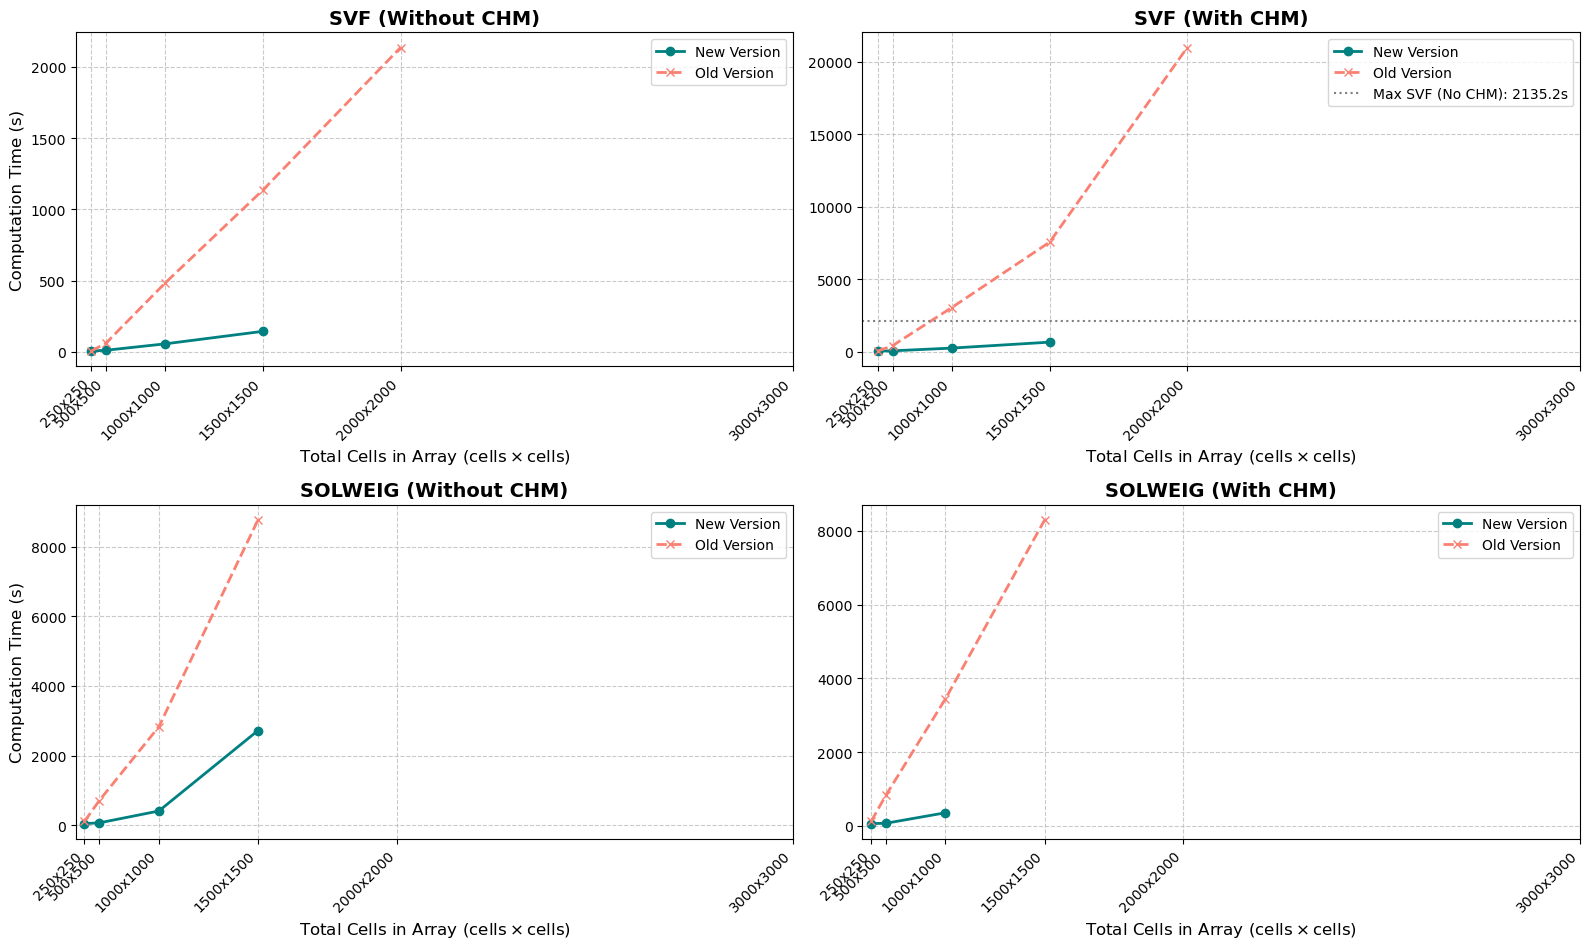

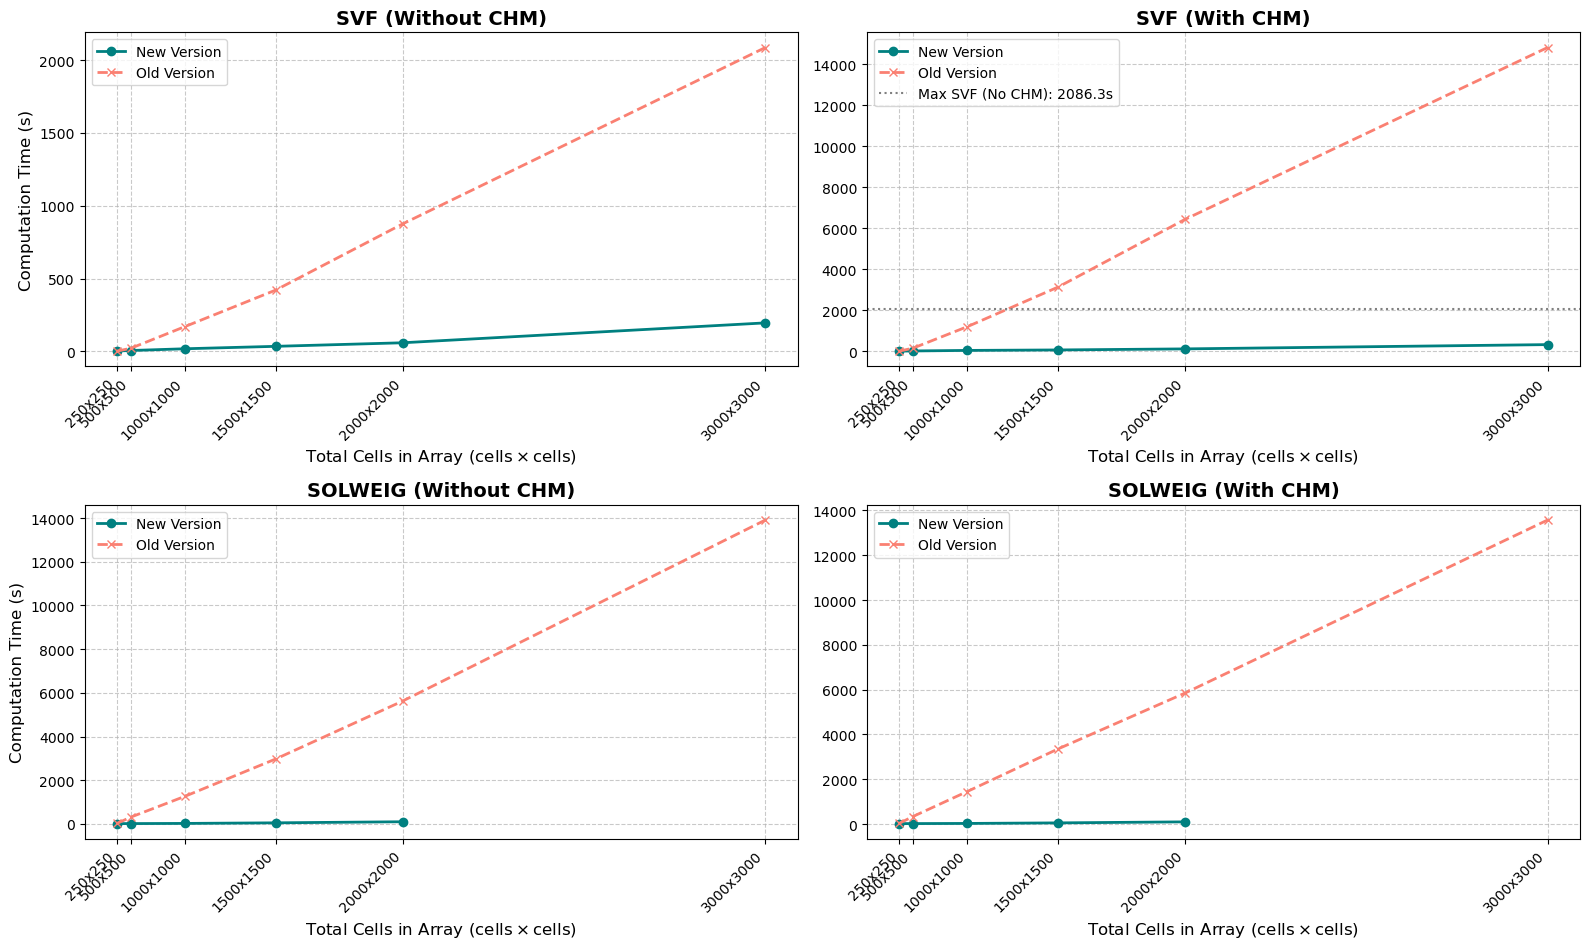

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data Loading ---
csv_file_path = '../../../datasets/profiling code/runtimes.csv'
df = pd.read_csv(csv_file_path, sep=',', na_values='NULL')
df.columns = df.columns.str.strip()



# Filter out columns
df_2d = df.loc[:, ~df.columns.str.contains('_3d')]

# Calculate the total number of cells for the x-axis values
df_2d['total_cells'] = df_2d['cells'] ** 2

# Create formatted X-axis labels (e.g., "250x250") from the 'cells' column
x_labels = [f'{c}x{c}' for c in df_2d['cells']]

# Define the types of plots (lap or com) to generate
plot_types = ['lap', 'com']

# Define the calculation types (SVF or SOLWEIG) for rows
calcs = ['svf', 'sol']

# Define the CHM statuses (building only or with CHM) for columns
chm_statuses = ['bud', 'chm']

subplot_titles = {
    'svf_bud': 'SVF (Without CHM)',
    'svf_chm': 'SVF (With CHM)',
    'sol_bud': 'SOLWEIG (Without CHM)',
    'sol_chm': 'SOLWEIG (With CHM)'
}

for plot_type in plot_types:
    fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharey=False)

    for i, calc in enumerate(calcs):
        for j, chm_status in enumerate(chm_statuses):
            ax = axs[i, j]

            col_new = f'{plot_type}_{calc}_{chm_status}_new_2d'
            col_old = f'{plot_type}_{calc}_{chm_status}_old_2d'

            ax.plot(df_2d['total_cells'], df_2d[col_new],
                    marker='o', linestyle='-', label='SOLFD',
                    color='teal', linewidth=2)

            ax.plot(df_2d['total_cells'], df_2d[col_old],
                    marker='x', linestyle='--', label='SOLWEIG',
                    color='salmon', linewidth=2)

            if calc == 'svf' and chm_status == 'chm':
                max_svf_bud_new = df_2d[f'{plot_type}_svf_bud_new_2d'].max()
                max_svf_bud_old = df_2d[f'{plot_type}_svf_bud_old_2d'].max()

                max_ref_value = max(max_svf_bud_new if pd.notna(max_svf_bud_new) else 0,
                                    max_svf_bud_old if pd.notna(max_svf_bud_old) else 0)

                if max_ref_value > 0:
                    ax.axhline(y=max_ref_value, color='gray', linestyle=':', linewidth=1.5,
                               label=f'Max SVF (No CHM): {max_ref_value:.1f}s')


            ax.set_xticks(df_2d['total_cells'])
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)

            ax.set_title(subplot_titles[f'{calc}_{chm_status}'], fontsize=14, fontweight='bold')
            ax.set_xlabel('Total Cells in Array ($ \\text{cells} \\times \\text{cells} $)', fontsize=12)

            if j == 0:
                ax.set_ylabel('Computation Time (s)', fontsize=12)
            ax.grid(True, which="both", ls="--", c='0.7', alpha=0.7)
            ax.legend(fontsize=10)


    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


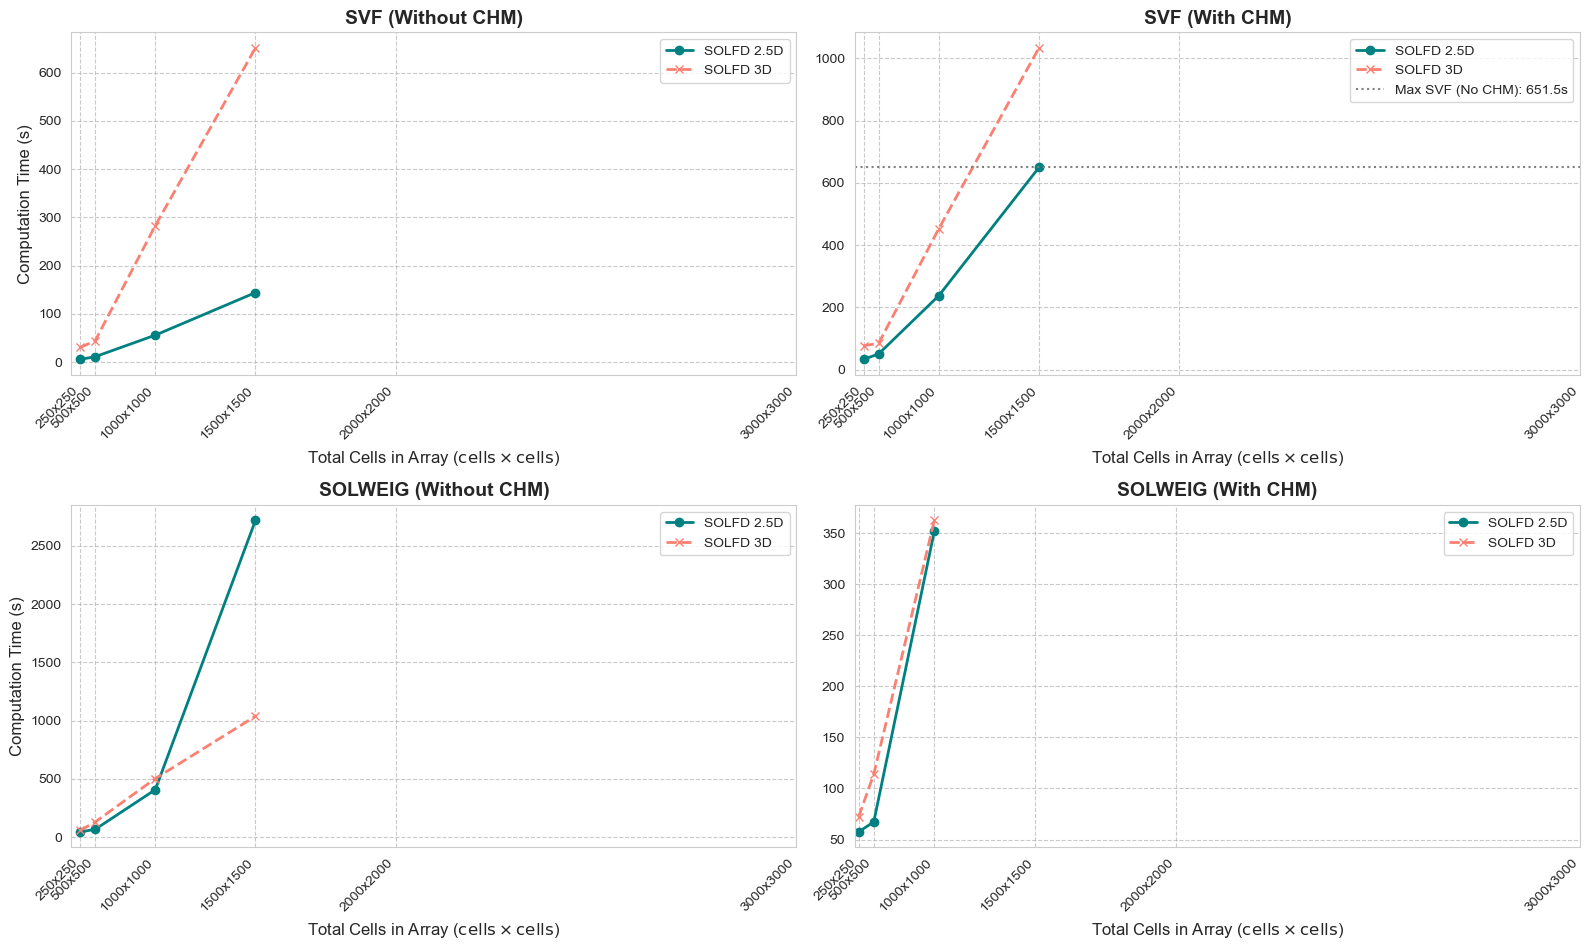

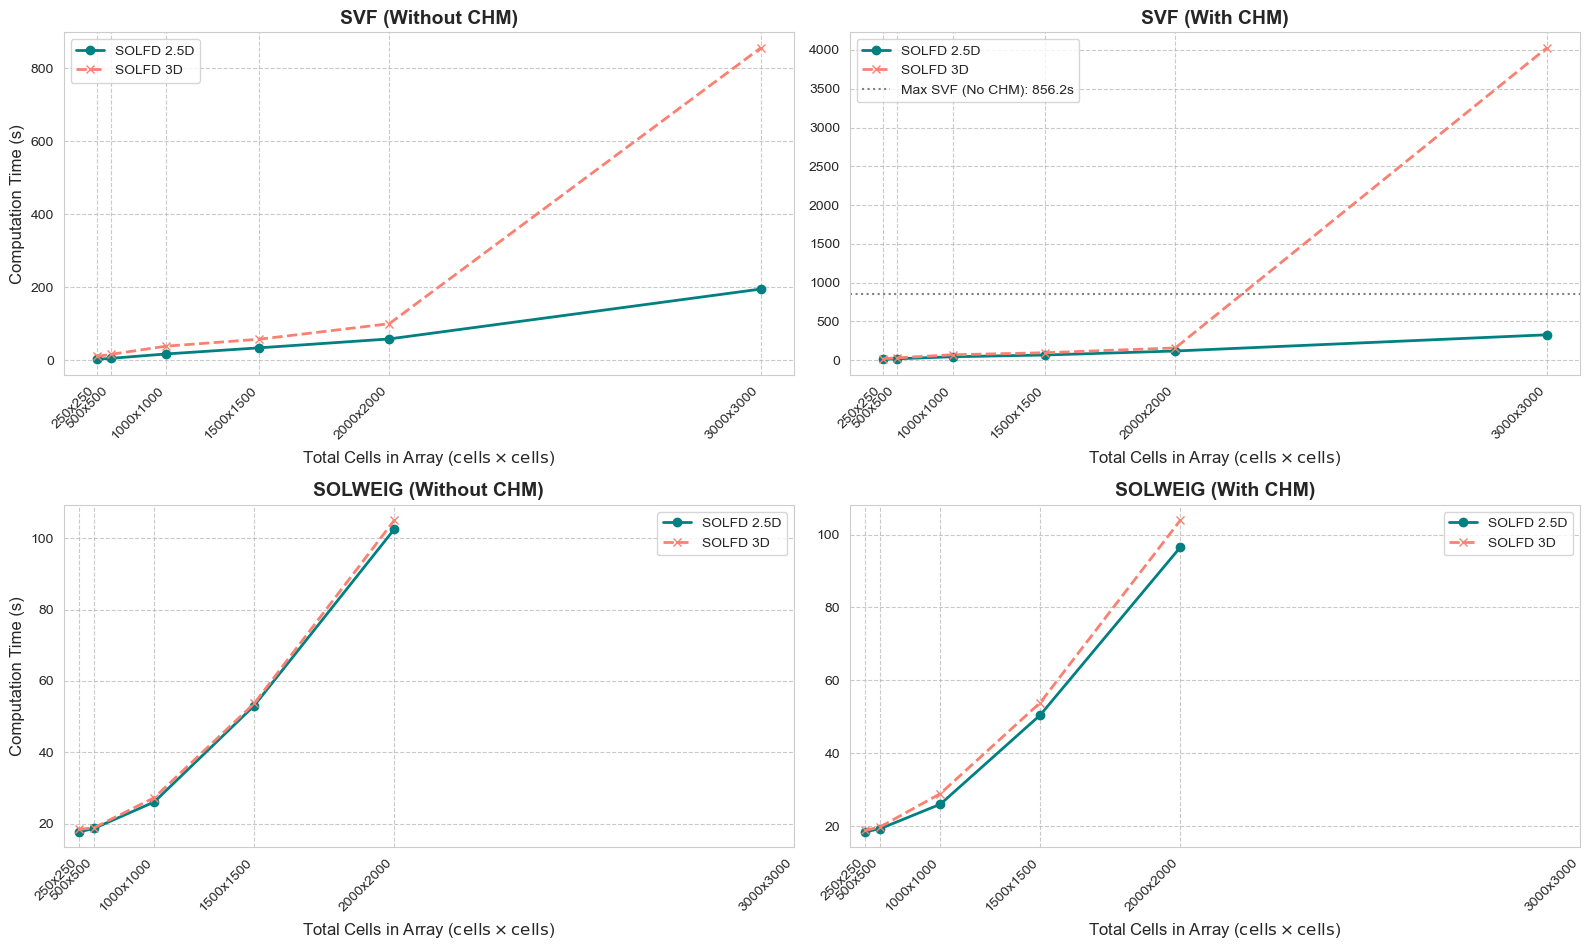

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# --- Data Loading ---
csv_file_path = '../../../datasets/profiling code/runtimes.csv'

df = pd.read_csv(csv_file_path, sep=',', na_values='NULL')

df.columns = df.columns.str.strip()

df_2d = df 

# Calculate the total number of cells for the x-axis values
df_2d['total_cells'] = df_2d['cells'] ** 2

# Create formatted X-axis labels (e.g., "250x250") from the 'cells' column
x_labels = [f'{c}x{c}' for c in df_2d['cells']]

# Define the types of plots (lap or com) to generate
plot_types = ['lap', 'com']

# Define the calculation types (SVF or SOLWEIG) for rows
calcs = ['svf', 'sol']

chm_statuses = ['bud', 'chm']

subplot_titles = {
    'svf_bud': 'SVF (Without CHM)',
    'svf_chm': 'SVF (With CHM)',
    'sol_bud': 'SOLWEIG (Without CHM)',
    'sol_chm': 'SOLWEIG (With CHM)'
}

for plot_type in plot_types:
    fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharey=False)

    for i, calc in enumerate(calcs):
        for j, chm_status in enumerate(chm_statuses):
            ax = axs[i, j] 

            col_new = f'{plot_type}_{calc}_{chm_status}_new_2d'
            col_old = f'{plot_type}_{calc}_{chm_status}_new_3d'

            ax.plot(df_2d['total_cells'], df_2d[col_new],
                    marker='o', linestyle='-', label='SOLFD 2.5D',
                    color='teal', linewidth=2)

            ax.plot(df_2d['total_cells'], df_2d[col_old],
                    marker='x', linestyle='--', label='SOLFD 3D',
                    color='salmon', linewidth=2)

            # --- Add reference line for SVF (Without CHM) max to SVF (With CHM) plot ---
            if calc == 'svf' and chm_status == 'chm':
                max_svf_bud_new = df_2d[f'{plot_type}_svf_bud_new_2d'].max()
                max_svf_bud_new_3d = df_2d[f'{plot_type}_svf_bud_new_3d'].max()

                max_ref_value = max(max_svf_bud_new if pd.notna(max_svf_bud_new) else 0,
                                    max_svf_bud_new_3d if pd.notna(max_svf_bud_new) else 0)

                if max_ref_value > 0:
                    ax.axhline(y=max_ref_value, color='gray', linestyle=':', linewidth=1.5,
                               label=f'Max SVF (No CHM): {max_ref_value:.1f}s')


            ax.set_xticks(df_2d['total_cells'])
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)

            ax.set_title(subplot_titles[f'{calc}_{chm_status}'], fontsize=14, fontweight='bold')
            ax.set_xlabel('Total Cells in Array ($ \\text{cells} \\times \\text{cells} $)', fontsize=12)
            if j == 0:
                ax.set_ylabel('Computation Time (s)', fontsize=12)

            ax.grid(True, which="both", ls="--", c='0.7', alpha=0.7)

            ax.legend(fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()